In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
from all_funcs import *

### Загружаем датасет

In [3]:
df = pd.read_csv('podcasts.csv')

In [4]:
#выводим первые 2 наблюдения
df.head(2)

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Healthy Living,Episode 77,99.25,Health,21.37,Thursday,Night,70.22,3,Positive,55.158695
1,Mystery Matters,Episode 6,19.43,True Crime,47.19,Friday,Evening,75.15,1,Neutral,7.686559


In [5]:
#Смотрим размерность датасета
df.shape

(52500, 11)

In [6]:
#выводим основные стат.показатели датасета. 
df.describe()

,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,47254.000000,52500.000000,47242.000000,52500.000000,47105.000000
mean,62.853491,60.163949,50.053434,1.497962,45.560293
std,33.137428,23.158567,28.884997,1.117412,27.182454
min,5.000000,20.000000,0.010000,0.000000,0.000000
25%,34.300000,40.000000,25.030000,0.000000,23.286442
50%,62.870000,60.300000,50.035000,1.000000,43.555490
75%,91.550000,80.310000,75.100000,2.000000,64.953793
max,120.000000,100.000000,100.000000,3.000000,119.970000


In [7]:
#валидируем датасет на пропуски и удаляем если их доля на тотале не превышает 15%
print(f"Пропуски в данных \n{df.isna().sum()}")
print('======================')

Пропуски в данных 
Podcast_Name                      0
Episode_Title                     0
Episode_Length_minutes         5246
Genre                             0
Host_Popularity_percentage        0
Publication_Day                   0
Publication_Time                  0
Guest_Popularity_percentage    5258
Number_of_Ads                     0
Episode_Sentiment                 0
Listening_Time_minutes         5395
dtype: int64


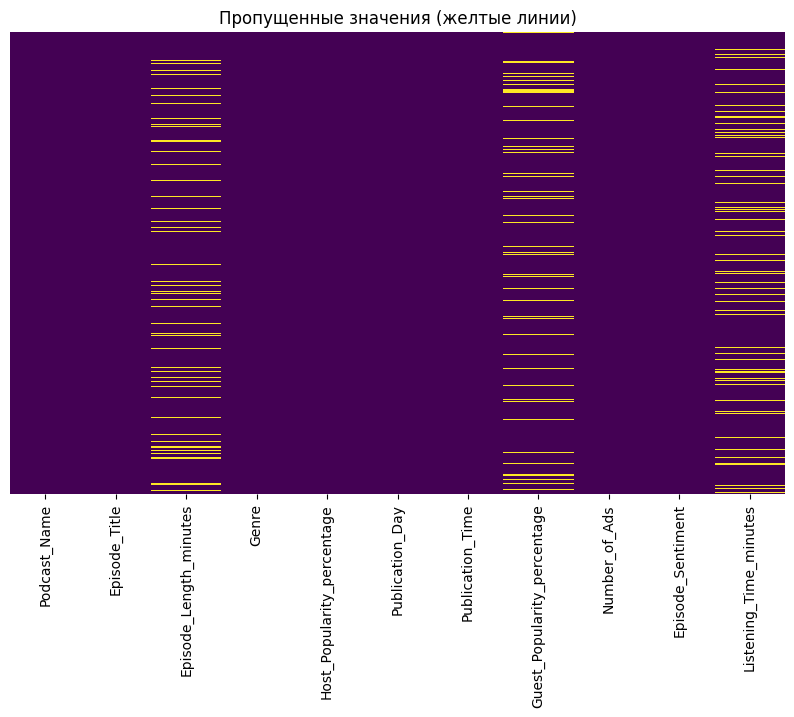

In [19]:
# Визуализация пропусков
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Пропущенные значения (желтые линии)')
plt.show()

In [8]:
check_null(df)

Доля 10.0% пропусков
38163
Доля пропусков на тотале меньше  30%. Удаляем пропуски


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Healthy Living,Episode 77,99.25,Health,21.37,Thursday,Night,70.22,3,Positive,55.158695
1,Mystery Matters,Episode 6,19.43,True Crime,47.19,Friday,Evening,75.15,1,Neutral,7.686559
2,Current Affairs,Episode 1,117.03,News,96.33,Sunday,Night,57.95,3,Neutral,110.064645
3,Mystery Matters,Episode 38,16.97,True Crime,25.73,Monday,Night,24.19,0,Positive,12.000380
6,Style Guide,Episode 76,63.77,Lifestyle,58.84,Saturday,Afternoon,82.20,0,Positive,57.827346
...,...,...,...,...,...,...,...,...,...,...,...
52494,Market Masters,Episode 23,33.35,Business,63.23,Monday,Morning,90.81,1,Positive,32.133509
52495,Home & Living,Episode 17,24.81,Lifestyle,66.15,Monday,Evening,98.63,1,Neutral,20.573795
52496,Melody Mix,Episode 9,92.15,Music,89.61,Saturday,Night,25.82,2,Negative,76.198459
52497,Comedy Corner,Episode 24,112.27,Comedy,26.33,Saturday,Night,55.29,0,Neutral,107.602135


In [9]:
#Смотрим на наличие дубликатов в данных

df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
52495     True
52496     True
52497     True
52498     True
52499     True
Length: 52500, dtype: bool

In [10]:
#Выборка одной пару дубликатов
df[(df['Podcast_Name'] == 'Business Briefs')& (df['Episode_Title'] == "Episode 85") & (df['Listening_Time_minutes'] == 17.220998)]

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
8484,Business Briefs,Episode 85,NaN,Business,41.47,Wednesday,Afternoon,33.58,0,Neutral,17.220998
52498,Business Briefs,Episode 85,NaN,Business,41.47,Wednesday,Afternoon,33.58,0,Neutral,17.220998


Т.к. у нас датасет представляет собой агрегированную информацию по прослушиваниям подкастов, то велика вероятность того, что были пользователя прослушавшие одинаковое кол-во времени. 
На данном этапе пока дубликаты оставляем

In [11]:
#выводим схему типов данных в датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52500 entries, 0 to 52499
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Podcast_Name                 52500 non-null  object 
 1   Episode_Title                52500 non-null  object 
 2   Episode_Length_minutes       47254 non-null  float64
 3   Genre                        52500 non-null  object 
 4   Host_Popularity_percentage   52500 non-null  float64
 5   Publication_Day              52500 non-null  object 
 6   Publication_Time             52500 non-null  object 
 7   Guest_Popularity_percentage  47242 non-null  float64
 8   Number_of_Ads                52500 non-null  int64  
 9   Episode_Sentiment            52500 non-null  object 
 10  Listening_Time_minutes       47105 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ MB


In [15]:
# категориальные и количественные фичи для дальнейшего анализа распределяем по переменным
numeric_features_columns = df.select_dtypes(np.number).columns
cat_features_columns = df.select_dtypes(object).columns
target_column = 'Listening_Time_minutes'

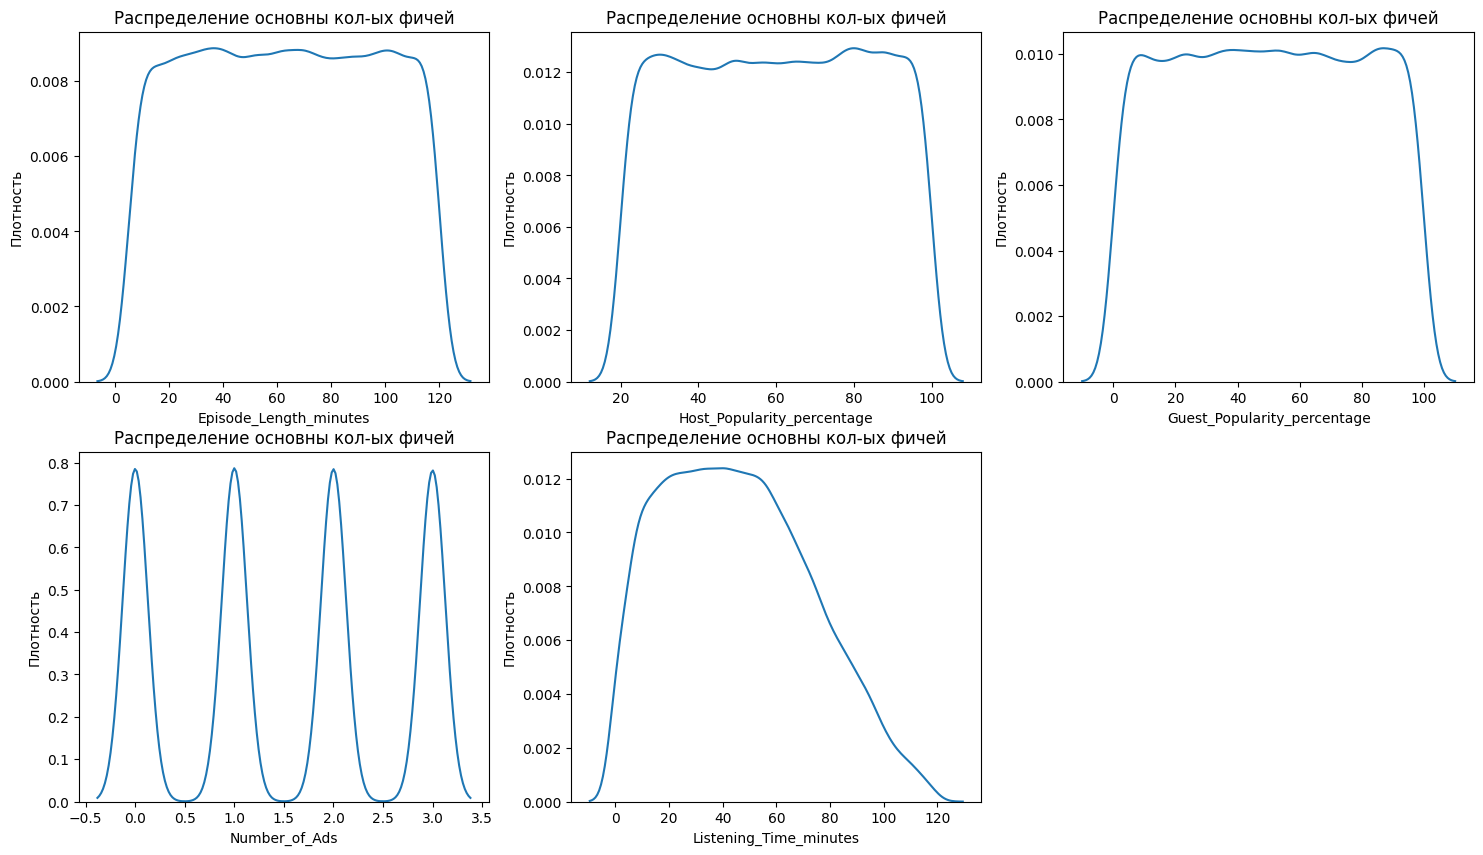

In [16]:
looking_into_numeric_features(data=df, num_col=numeric_features_columns)

Видим, что плотность распределений везде практически идентична.

Во времени прослушивания видим, смещение распределения влево т.е. большая часть прослушиваний подкастов пользователями краткосрочна т.к. длина подкастов по времени у нас в целом распределено равномерно. 



Проанализируем дополнительно распределение таргета

Скошенность: 0.34


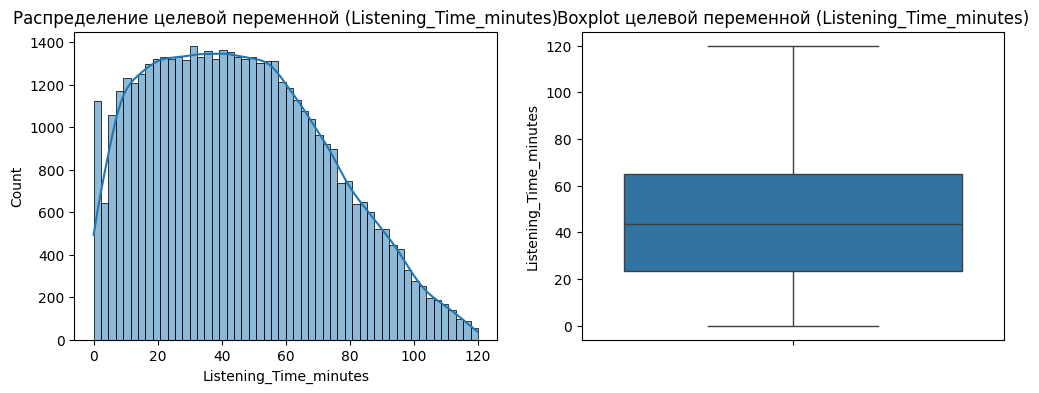

In [13]:
# Создаем фигуру с двумя subplot. Первая фигура покажет распределение целевой переменной (histplot), на второй сможем увидеть выбросы (boxplot).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 1. Гистограмма с ядром плотности (KDE)
sns.histplot(data=df, x='Listening_Time_minutes', kde=True, ax=axes[0])
axes[0].set_title('Распределение целевой переменной (Listening_Time_minutes)')

# 2. Boxplot для поиска выбросов
sns.boxplot(data=df, y='Listening_Time_minutes', ax=axes[1])
axes[1].set_title('Boxplot целевой переменной (Listening_Time_minutes)')

# Выведем (скошенность) распределения
print(f"Скошенность: {df['Listening_Time_minutes'].skew():.2f}")

Проанализируем связи между количественными переменными и таргетом

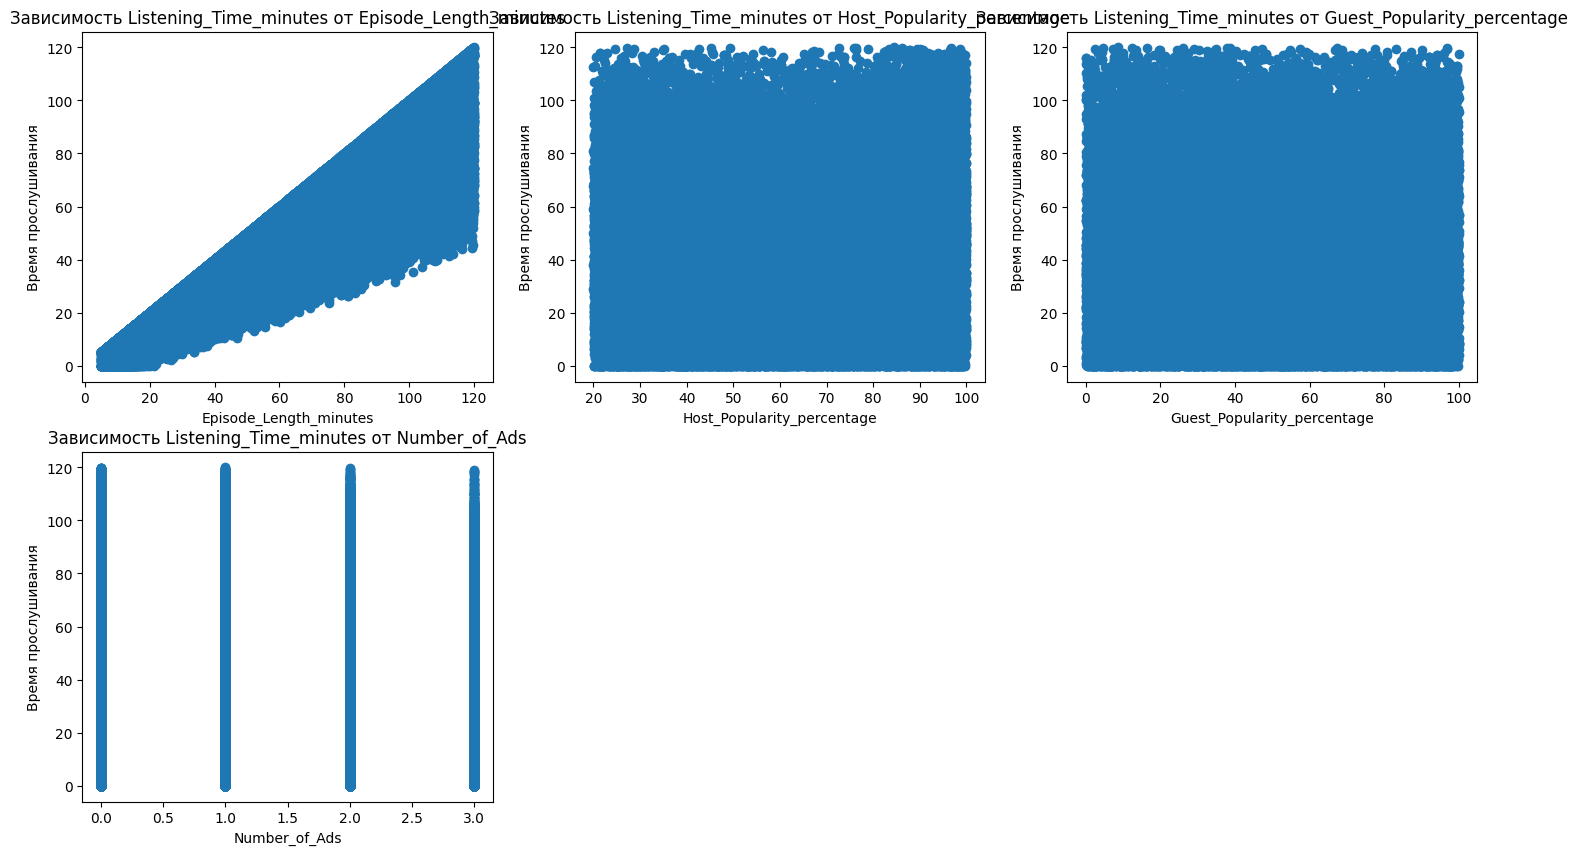

In [17]:
plots_correlation_numeric_features_with_target(data=df, num_col=numeric_features_columns)

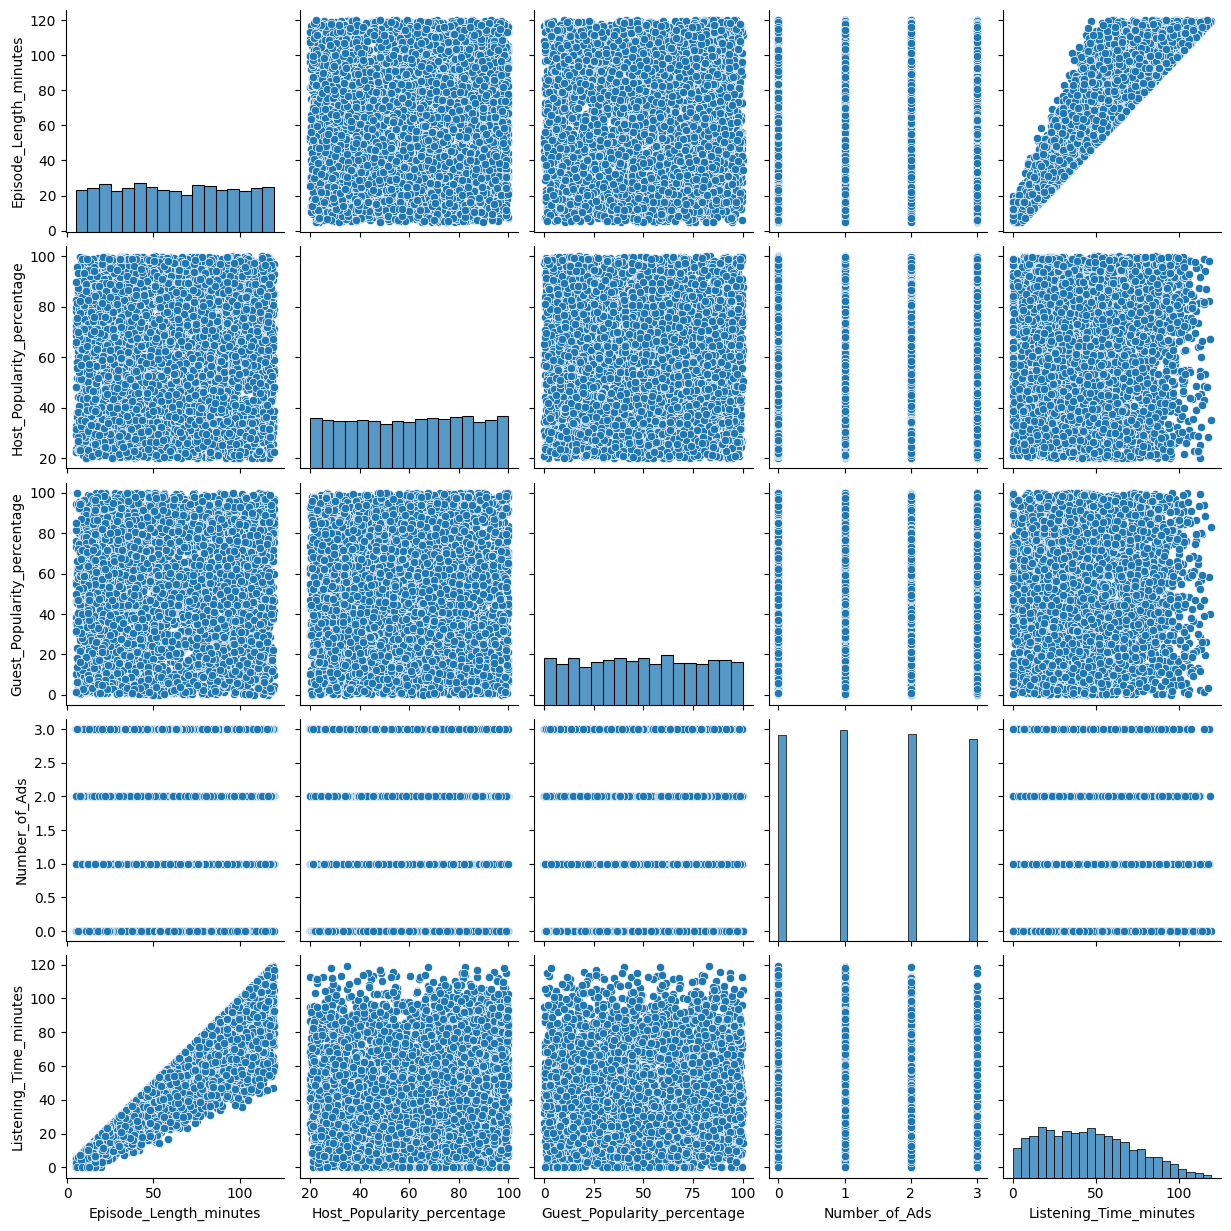

In [18]:
# Можно построить общие графики интересующих нас признаков на одной странице для ЧИСЛОВЫХ данных (pairplot)
sample_df = df.sample(n=5000, random_state=42) if len(df) > 5000 else df
sns.pairplot(sample_df[numeric_features_columns], height=2.5)
plt.show()

С целевым таргетом коррелирует продолжительность подкаста. Рассмотрим на сколько сильна эта связь

<Axes: >

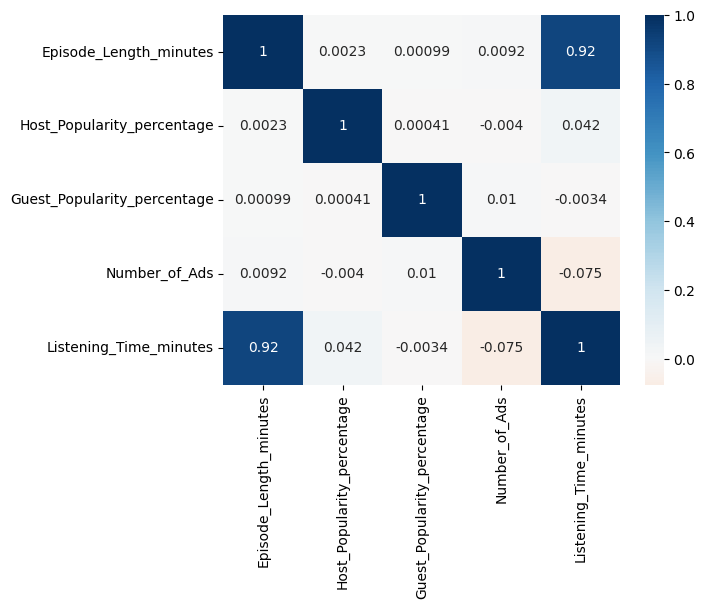

In [32]:
#Строим корреляционную темпловую карту

sns.heatmap(data=df[numeric_features_columns].corr(method='spearman'), annot=True, cmap='RdBu', center=0)

### Наблюдаем сильную корреляцию таргета с длительностью подкаста = 0.92. 

In [33]:
print(search_multicollinear(df=df, num_col=numeric_features_columns))

Мультиколлинеарность незначительная или отсутствует вовсе 
                       feature        VIF
0                        const  16.782010
1       Episode_Length_minutes   1.000081
2   Host_Popularity_percentage   1.000021
3  Guest_Popularity_percentage   1.000096
4                Number_of_Ads   1.000187


/Users/poltava/Desktop/ML_practice/Linear_regression/all_funcs.py:56: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if vif_df.iloc[1:,:].max()[1] > 10:
/Users/poltava/Desktop/ML_practice/Linear_regression/all_funcs.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif vif_df.iloc[1:,:].max()[1] < 10 and vif_df.iloc[1:,:].max()[1] > 5:
/Users/poltava/Desktop/ML_practice/Linear_regression/all_funcs.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, u

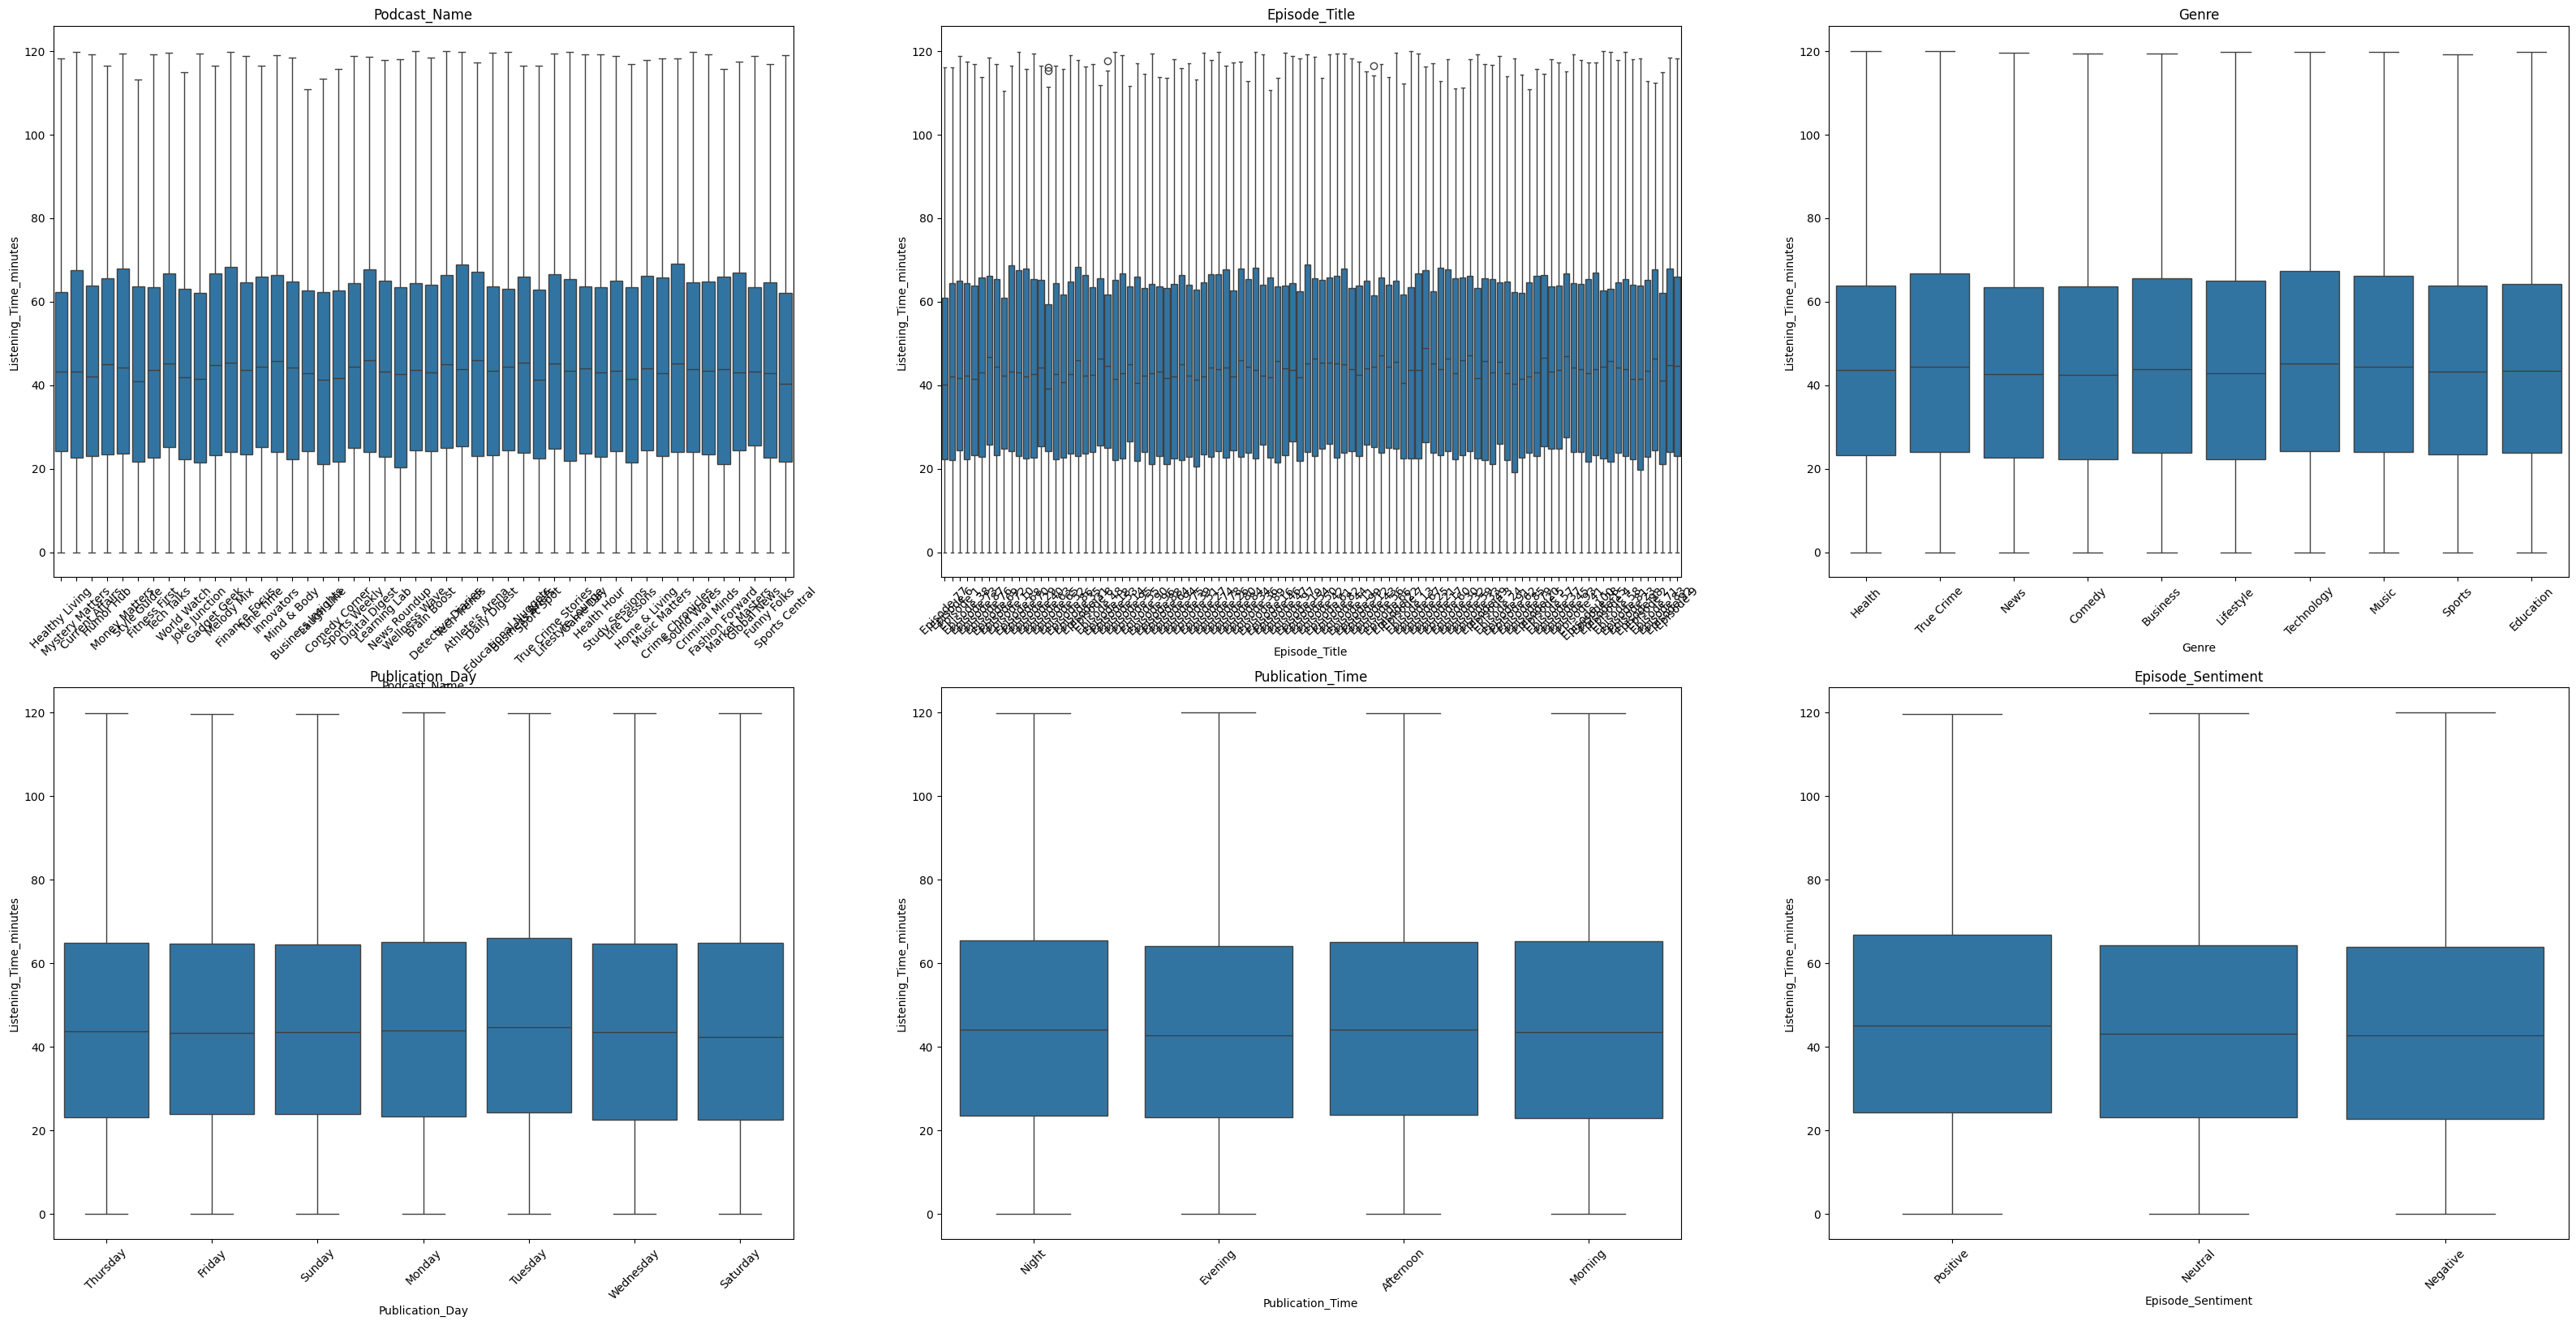

In [34]:
categorial_feat_boxplots(data=df, cat_feat=cat_features_columns, target=target_column)